### Load Functions

In [27]:
# load svm classifier and hypercube with no NaN values

def predict_svm(svm_classifier, hypercube):
    
    rows, cols, bands = hypercube.shape
    image_reshaped = hypercube.reshape(rows * cols, bands)

    # Predict the class for every pixel
    predicted_labels = svm_classifier.predict(image_reshaped)

    # Reshape the prediction back into a 2D image mask
    pred_mask = predicted_labels.reshape(rows, cols)

    return pred_mask


# --- Visualize the huge improvement ---
import matplotlib.pyplot as plt

def viz(final_mask, img, random_band=45):

    fig, axes = plt.subplots(1, 2, figsize=(9, 5))

    single_band = img.read_band(random_band)
    axes[0].imshow(single_band, cmap='gray')
    axes[0].set_title('Origninal')

    axes[1].imshow(final_mask, cmap='gray')
    axes[1].set_title('SVM Mask')
    plt.show()


from skimage.morphology import remove_small_objects, remove_small_holes, opening, disk
import spectral.io.envi as envi
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import os


def viz_all(initial_mask, final_mask, img, random_band=45):

    fig, axes = plt.subplots(1, 3, figsize=(9, 5))

    axes[0].imshow(initial_mask, cmap='gray')
    axes[0].set_title('Initial Mask')

    single_band = img.read_band(random_band)

    axes[1].imshow(single_band, cmap='gray')
    axes[1].set_title('Origninal')

    axes[2].imshow(final_mask, cmap='gray')
    axes[2].set_title('Final Mask')
    plt.show()


# --- Post-processing steps ---
def post_process(mask, max_size_small_objects=30, max_size_holes=1, radius=3.5):

    # converting the integer array with 0 and 1s into a boolean as skimage.morphology expects boolean array
    mask = mask.astype(bool)
    mask1 = remove_small_objects(mask, max_size=max_size_small_objects)

    # 2. Fill small black holes inside the plant
    # '150' is the maximum size of a hole to be filled.
    mask2 = remove_small_holes(mask1, max_size=max_size_holes)
    
    # 3. Opening: 
    selem = disk(radius)

    # Apply the opening operation
    final_mask = opening(mask2, selem)

    return final_mask



### extract mask and reflectance

In [2]:
# load trained SVM model

import joblib

svm_classifier = joblib.load('trained_svm_model.joblib')
svm_classifier

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",550
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
from pathlib import Path

folder = Path(r"C:\Users\baolab\Downloads\biochar_data\BH9010")

hdr_files = list(folder.glob("*.hdr"))


In [33]:

base_names = [f.stem for f in hdr_files]

print(base_names)


['9010_Oven dried_16_113_2026-02-16_21-01-19_', '9010_Oven dried_31_30_2026-02-19_14-06-59_', '9010_Oven dried_38_47_2026-02-19_14-23-38_']


In [34]:
for name in base_names:
    
    hdr_file = folder / f"{name}.hdr"
    bin_file = folder / f"{name}.bin"

    print(hdr_file, bin_file)

C:\Users\baolab\Downloads\biochar_data\BH9010\9010_Oven dried_16_113_2026-02-16_21-01-19_.hdr C:\Users\baolab\Downloads\biochar_data\BH9010\9010_Oven dried_16_113_2026-02-16_21-01-19_.bin
C:\Users\baolab\Downloads\biochar_data\BH9010\9010_Oven dried_31_30_2026-02-19_14-06-59_.hdr C:\Users\baolab\Downloads\biochar_data\BH9010\9010_Oven dried_31_30_2026-02-19_14-06-59_.bin
C:\Users\baolab\Downloads\biochar_data\BH9010\9010_Oven dried_38_47_2026-02-19_14-23-38_.hdr C:\Users\baolab\Downloads\biochar_data\BH9010\9010_Oven dried_38_47_2026-02-19_14-23-38_.bin


In [35]:
from biochar.biochar_utils import load_spectral_cube
from biochar.biochar_utils import get_biochar_reflectance


c:\ProgramData\anaconda3\envs\hyperspec\Lib\site-packages\spectral\io\spyfile.py:224: NaNValueWarning: Image data contains NaN values.
  warnings.warn('Image data contains NaN values.', NaNValueWarning)


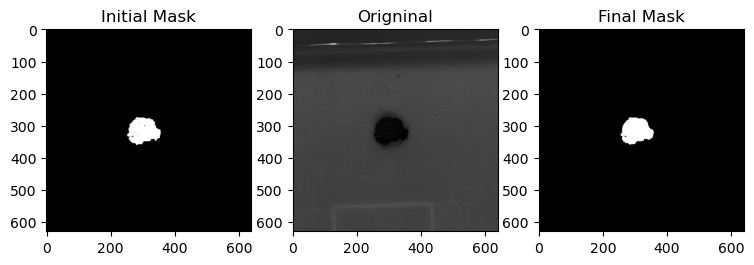

Saved mask as PNG.
Found 1 distinct objects. Processing...
Successfully saved 1 individual reflectance cubes, the full mask image, and the reflectance CSV.


c:\ProgramData\anaconda3\envs\hyperspec\Lib\site-packages\spectral\io\spyfile.py:224: NaNValueWarning: Image data contains NaN values.
  warnings.warn('Image data contains NaN values.', NaNValueWarning)


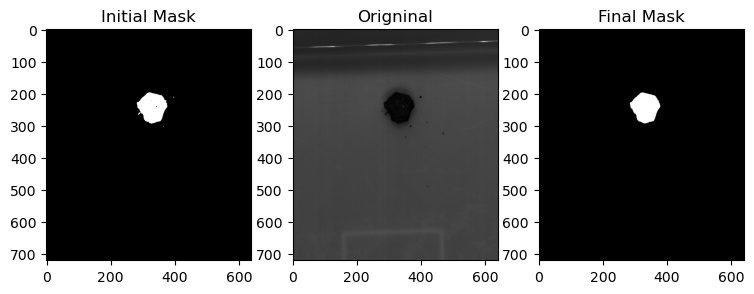

Saved mask as PNG.
Found 1 distinct objects. Processing...
Successfully saved 1 individual reflectance cubes, the full mask image, and the reflectance CSV.


c:\ProgramData\anaconda3\envs\hyperspec\Lib\site-packages\spectral\io\spyfile.py:224: NaNValueWarning: Image data contains NaN values.
  warnings.warn('Image data contains NaN values.', NaNValueWarning)


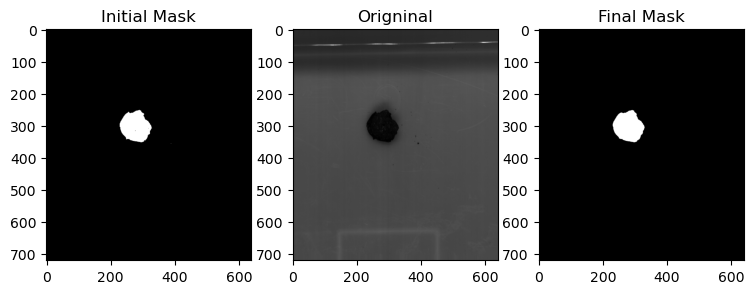

Saved mask as PNG.
Found 1 distinct objects. Processing...
Successfully saved 1 individual reflectance cubes, the full mask image, and the reflectance CSV.


In [37]:

for name in base_names:
    
    hdr_file = folder / f"{name}.hdr"
    bin_file = folder / f"{name}.bin"
    
    hypercube_arr, img_cube = load_spectral_cube(hdr_file, bin_file)
    
    new_mask = predict_svm(svm_classifier, hypercube_arr)
    final_mask = post_process(new_mask, 30, 10, 5)
    viz_all(new_mask, final_mask, img_cube)

    get_biochar_reflectance(hypercube_arr, final_mask, output_dir = f'biochar_results/{name}')
